In [184]:
import torch
from dinosaw.models.vit_wrapper import MODEL_LIST, PretrainedViTWrapper, AlibiVitWrapper
from dinosaw.comaprisons.denoising_vits import DenoisingViTWrapper 
from dinosaw.linear_probe import get_ramp, gen_sample_mask, do_linear_probe, LinearProbeResult
from dinosaw.utils import do_2D_pca, to_numpy, closest_resize, convert_image, load_image

import numpy as np
from PIL import Image

import matplotlib.pyplot as plt

SEED = 100001
torch.manual_seed(SEED)
np.random.seed(SEED)

half = False

In [185]:
S = 14
dv2_model = PretrainedViTWrapper(
    MODEL_LIST[1],
    stride=S,
    add_flash_attn=False,
    device="cuda:0",
)

dv2_model.eval()
if half:
    dv2_model.half()
None

In [186]:
dvt_model = DenoisingViTWrapper(
    '../../trained_models/dvt.pth',
    MODEL_LIST[1],
    stride=S,
    add_flash_attn=False,
    device="cuda:0",
)
dvt_model.eval()
if half:
    dvt_model.half()
None

In [187]:
alibi_model = AlibiVitWrapper(
    MODEL_LIST[1],
    stride=S,
    add_flash_attn=False,
    device="cuda:0",
    slope_type="constant",
    normalize=True,
    wrap=True,
)

# weights = torch.load("../../trained_models/alibi_dv2_vits14_reg.pth", weights_only=True, map_location="cuda:0")
weights = torch.load("../../experiments/20260128_0957/best_model.pth", weights_only=True, map_location="cuda:0")
alibi_model.load_state_dict(weights)
alibi_model.eval()
if half:
    alibi_model.half()
None

In [188]:
alibi_homog_model = AlibiVitWrapper(
    MODEL_LIST[1],
    stride=S,
    add_flash_attn=False,
    device="cuda:0",
    slope_type="constant",
    normalize=True,
    wrap=True,
)

weights = torch.load("../../trained_models/alibi_homog_dv2_vits14_reg.pth", weights_only=True, map_location="cuda:0")
alibi_homog_model.load_state_dict(weights)
alibi_homog_model.eval()
if half:
    alibi_homog_model.half()
None

In [189]:
def get_features(model: PretrainedViTWrapper, pil_img: Image.Image, channel_last: bool=True, channel_blank: bool=False) -> np.ndarray:
    tr = closest_resize(pil_img.height, pil_img.width, 14)
    img_tensor = convert_image(pil_img, tr, device_str="cuda:0", to_half=half)
    with torch.no_grad():
        emb = model.forward_features(img_tensor, make_2D=True)
    emb_np = to_numpy(emb.squeeze(0))
    if channel_blank:
        channels_to_blank = [47, 113, 117, 359]
        emb_np[channels_to_blank, :, :] = 0
    if channel_last:
        emb_np = np.transpose(emb_np, (1, 2, 0))

    return emb_np

In [190]:
SF = 1

# img_fname = "micro/NMC_2D_crop.png"
# img_fname = "tests/black_square_518.png"
img_fname = "tests/default_image_518.png"
# img_fname = "micro/000394.jpg"
# img_fname = "labradors.png"
# img_fname = "tests/z_c_w.png"
# img_fname = "micro/NMC_2D_wide_crop.png"
_img = Image.open(f"../../images/{img_fname}").convert("RGB")
_img = _img.resize((int(SF * _img.width), int(SF * _img.height)), Image.LANCZOS)

In [191]:
keys: tuple[str] = ('dv2', 'dvt', 'alibi', 'alibi_h')
names: dict[str, str] = {'dv2': 'DINOv2', 'dvt': "DVT", "alibi": "ALiBi-Dv2", "alibi_h": "ALiBi(H)-Dv2"}
models: dict[str, PretrainedViTWrapper] = {'dv2': dv2_model, 'dvt': dvt_model, 'alibi': alibi_model, 'alibi_h': alibi_homog_model}

enabled_models = keys

results: dict[str, LinearProbeResult] = {}
feats_reduced: dict[str, np.ndarray] = {}


In [192]:
ramp_type = 'ud'
chosen_vis_model = 'dv2'

In [193]:
for model_key in enabled_models:
    model = models[model_key]
    feats = get_features(model, _img, True, False)
    probe_res = do_linear_probe(feats, ramp_type, probe_by_channel=True)

    results[model_key] = probe_res
    feats_reduced[model_key] = do_2D_pca(feats.transpose((2, 0, 1)), 3, pre_norm='std', post_norm='minmax')

In [194]:
from matplotlib.gridspec import GridSpec
from matplotlib.patches import Rectangle
from matplotlib.collections import PatchCollection

def add_red_square_overlay(ax: plt.Axes, mask: np.ndarray, sf_h: float, sf_w: int) -> None:
    patches: list[Rectangle] = []
    y_inds, x_inds  = np.nonzero(mask)
    for x, y in zip(x_inds, y_inds):
        rect = Rectangle((x - sf_w / 2, y - sf_h / 2), sf_w, sf_h)
        patches.append(rect)
    pc = PatchCollection(patches, color='red', facecolor='none')
    ax.add_collection(pc)


def set_axes_off(ax: plt.Axes):
    ax.set_xticks([])
    ax.set_yticks([])

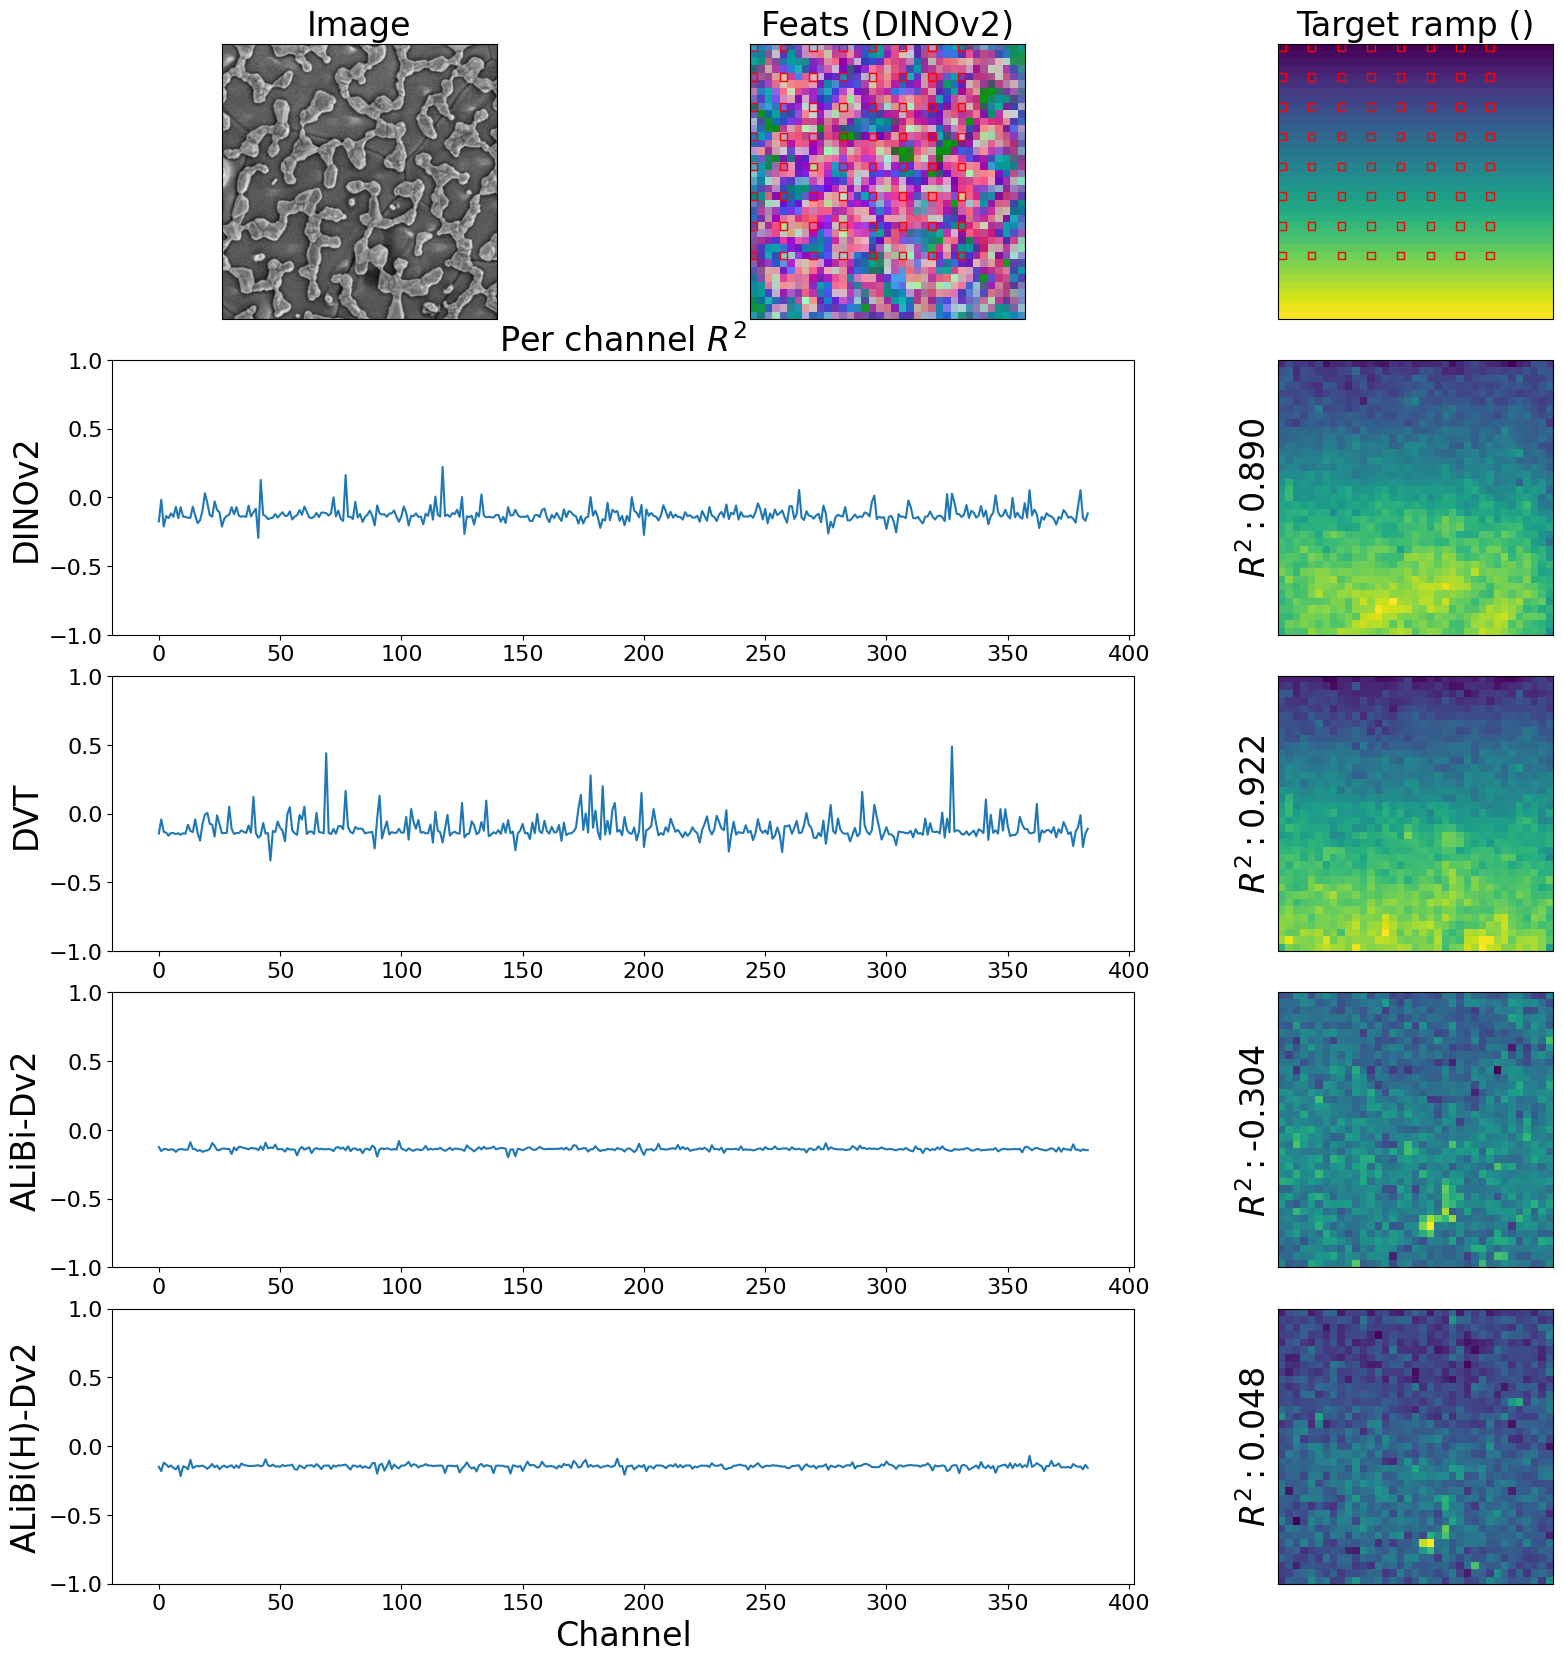

In [195]:
FS = 24


fig = plt.figure(figsize=(20, 20))
gs = GridSpec(1 + len(enabled_models), 3, wspace=0.07, hspace=0.15, width_ratios=[1, 1, 1])


img_ax = fig.add_subplot(gs[0,0])
img_ax.imshow(_img)
set_axes_off(img_ax)
img_ax.set_title("Image", fontsize=FS)

pca_ax = fig.add_subplot(gs[0, 1])
pca_ax.imshow(feats_reduced[chosen_vis_model])
set_axes_off(pca_ax)
pca_ax.set_title(f"Feats ({names[chosen_vis_model]})", fontsize=FS)


h ,w = (_img.height // S, _img.width // S)
ramp = get_ramp(ramp_type, h, w)
mask = gen_sample_mask((h, w), ramp_type, cutoff_frac=0.8)

ramp_ax = fig.add_subplot(gs[0, 2])
ramp_ax.imshow(ramp)
set_axes_off(ramp_ax)
ramp_ax.set_title("Target ramp ()", fontsize=FS)

add_red_square_overlay(pca_ax, mask, 1,  1)
add_red_square_overlay(ramp_ax, mask, 1,  1)


colors = {'dv2': ''}

for i, model_key in enumerate(enabled_models):
    probe_res = results[model_key]

    scores_ax = fig.add_subplot(gs[i + 1, 0:2])
    scores_ax.set_ylabel(f"{names[model_key]}", fontsize=FS)
    scores_ax.plot(probe_res['per_channel_scores'])
    scores_ax.set_ylim(-1, 1)
    scores_ax.tick_params(axis='both', which='major', labelsize=FS - 8)

    if i == 0:
        scores_ax.set_title('Per channel ' +"$R^{2}$", fontsize=FS)
    if i == len(enabled_models) - 1:
        scores_ax.set_xlabel('Channel', fontsize=FS)
        # scores_ax.set_ylabel("$R^{2}:$")

    pred_ax = fig.add_subplot(gs[i + 1, 2])
    pred_ax.imshow(probe_res['stack_pred'])
    pred_ax.set_ylabel(r"$R^{2}: $" + f"{probe_res['stack_r_squared']:.3f}", fontsize=FS)
    set_axes_off(pred_ax)
